### WikiArt Web Scraper 

Art Guide github repo: https://github.com/aguschin/art-guide.git 

WikiArt Scraper: https://github.com/michaelvin1322/scrapWikiArt.git 

Used to update metadata for Paintings and Artists Tables

### Database Tables

`\c ART_RECSYS_DB`

`\copy artists FROM 'C:\Users\danie\Desktop\_\Daniela Curmi\University\Final Year Project\Final Year Project Code Implementation\Testing scripts\metadata_backup\artist_metadata_fixed.csv' CSV HEADER;`

`\copy paintings(painting_id, artist_id, title, year_created, genre, art_style, media, description_tags, image_path) FROM 'C:\Users\danie\Desktop\_\Daniela Curmi\University\Final Year Project\Final Year Project Code Implementation\Testing scripts\painting_metadata_features.csv' WITH (FORMAT csv, HEADER);`

In [89]:
import os
import re
import pandas as pd
import unicodedata
from matplotlib.patches import Patch
import psycopg2
import matplotlib.pyplot as plt
import numpy as np

### Paintings Table

#### Add artist ID to map artist details from artist table to paintings table

In [ ]:
# Load the metadata CSV and create artist table (unique artist only)
df = pd.read_csv("metadata_features_extracted.csv")
artists = df[['artist']].drop_duplicates().reset_index(drop=True)

# Assign artist IDs
artists['artist_id'] = artists.index + 1
artists = artists[['artist_id', 'artist']]

# Map artist_id back to metadata table
df = df.drop(columns=['artist_id'], errors='ignore')
df = df.merge(artists, on='artist', how='left')

# Move artist_id column next to painting_id
cols = list(df.columns)
cols.insert(1, cols.pop(cols.index('artist_id')))
df = df[cols]

# Save updated paintings metadata and artist CSV  
df.to_csv("painting_metadata_features.csv", index=False)
artists.to_csv("artist.csv", index=False)
print("Finished generating files.")

Finished generating files.


#### Add relative image paths to paintings table 

In [ ]:
# Paths
csv_path = "painting_metadata_features.csv"
paintings_root = r"C:\Users\danie\Desktop\_\Daniela Curmi\University\Final Year Project\Final Year Project Code Implementation\Website\paintings"

df = pd.read_csv(csv_path)

image_paths = []

for style_folder in sorted(os.listdir(paintings_root)):
    full_style_path = os.path.join(paintings_root, style_folder)

    if os.path.isdir(full_style_path):
        for img in sorted(os.listdir(full_style_path)):
            if img.lower().endswith((".jpg",".jpeg",".png",".webp")):
                image_paths.append(os.path.join("paintings", style_folder, img))

df["image_path"] = image_paths[:len(df)]

# Save updated CSV
df.to_csv("painting_metadata_features.csv", index=False)
print("Image paths added successfully.")

True
Image paths added successfully.


In [ ]:
# Files
metadata_file = "painting_metadata_features.csv"
paintings_file = r'C:\Users\danie\Desktop\_\Daniela Curmi\University\Final Year Project\Final Year Project Code Implementation\scrapWikiArt\data\art.csv'

# Load datasets
meta_df = pd.read_csv(metadata_file, encoding="cp1252")
paintings_df = pd.read_csv(paintings_file)

# Clean column names
meta_df.columns = meta_df.columns.str.strip()
paintings_df.columns = paintings_df.columns.str.strip()

# Keep only relevant columns
paintings_df = paintings_df[[
    "Title",
    "Genre",
    "Media",
    "Tags",
    "Date"
]]

# Rename columns to match metadata schema
paintings_df = paintings_df.rename(columns={
    "Title": "title",
    "Genre": "genre",
    "Media": "media",
    "Tags": "description_tags",
    "Date": "date_raw",
})

# Normalize names for matching
meta_df["title"] = meta_df["title"].str.strip().str.lower()
paintings_df["title"] = paintings_df["title"].str.strip().str.lower()

# remove duplicates
paintings_df["tag_len"] = paintings_df["description_tags"].fillna("").str.len()

paintings_df = (
    paintings_df
    .sort_values("tag_len", ascending=False)
    .drop_duplicates(subset="title", keep="first")
    .drop(columns="tag_len")
)

# Merge
merged = meta_df.merge(
    paintings_df,
    on="title",
    how="left",
    suffixes=("", "_new")
)

# Fill empty columns in metadata
for col in ["genre", "media", "description_tags"]:
    merged[col] = merged[col].combine_first(merged[f"{col}_new"])

def normalize_tags(text):
    if not isinstance(text, str):
        return text
    
    parts = []
    
    for token in text.split(","):
        # Handle hyphen-separated words
        hyphen_parts = token.split("-")
        hyphen_parts = [w.capitalize() for w in hyphen_parts if w]
        parts.append("-".join(hyphen_parts))
    
    return ",".join(parts)

merged["description_tags"] = merged["description_tags"].apply(normalize_tags)

# Extract year from Date column
def extract_year(date):
    if isinstance(date, str):
        match = re.search(r"\b(1[0-9]{3}|20[0-9]{2})\b", date)
        if match:
            return match.group(0)
    return None

merged["extracted_year"] = merged["date_raw"].apply(extract_year)

# Fill year_created only if Unknown
mask = (merged["year_created"].astype(str).str.lower() == "unknown") & (merged["extracted_year"].notna())
merged.loc[mask, "year_created"] = merged.loc[mask, "extracted_year"]

# Remove temporary columns
merged = merged.drop(columns=[c for c in merged.columns if c.endswith("_new")] + ["date_raw", "extracted_year"])

# Save result
merged.to_csv("painting_metadata_updated.csv", index=False)

print("Painting metadata successfully populated.")

C:\Users\danie\AppData\Local\Temp\ipykernel_4996\4222359825.py:7: DtypeWarning: Columns (2,3,7,10,11,12,17,18,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,2

Painting metadata successfully populated.


### Artists Table

In [ ]:
# Files
metadata_file = "artist_metadata.csv"
paintings_file = r'C:\Users\danie\Desktop\_\Daniela Curmi\University\Final Year Project\Final Year Project Code Implementation\scrapWikiArt\data\artists.csv'

# Load datasets
meta_df = pd.read_csv(metadata_file, encoding="cp1252")
paintings_df = pd.read_csv(paintings_file)

# Clean column names
meta_df.columns = meta_df.columns.str.strip()
paintings_df.columns = paintings_df.columns.str.strip()

# Function to extract year
def extract_year(value):
    if pd.isna(value):
        return None
    match = re.search(r"\d{4}", str(value))
    return match.group(0) if match else None

# Extract years
paintings_df["birth_year"] = paintings_df["BirthDate"].apply(extract_year)
paintings_df["death_year"] = paintings_df["DeathDate"].apply(extract_year)

# Keep only relevant columns
paintings_df = paintings_df[[
    "Name",
    "birth_year",
    "death_year",
    "Nationality",
    "Fields",
    "ArtMovements",
    "WikiDescription"
]]

# Rename columns to match metadata schema
paintings_df = paintings_df.rename(columns={
    "Name": "name_surname",
    "Nationality": "nationality",
    "Fields": "fields",
    "ArtMovements": "art_movements",
    "WikiDescription": "bio"
})

# Normalize names for matching
meta_df["name_surname"] = meta_df["name_surname"].str.strip().str.lower()
paintings_df["name_surname"] = paintings_df["name_surname"].str.strip().str.lower()

# Merge
merged = meta_df.merge(
    paintings_df,
    on="name_surname",
    how="left",
    suffixes=("", "_new")
)

# Fill empty columns in metadata
for col in ["birth_year", "death_year", "nationality", "fields", "art_movements", "bio"]:
    merged[col] = merged[col].combine_first(merged[f"{col}_new"])

# Remove temporary columns
merged = merged.drop(columns=[c for c in merged.columns if c.endswith("_new")])

# Save result
merged.to_csv("artist_metadata_1.csv", index=False)

print("Artist metadata successfully populated.")

Artist metadata successfully populated.


#### Fix encoding of special characters in CSV files before moving to DB

In [ ]:
df = pd.read_csv("artist_metadata_1.csv", encoding="utf-8", encoding_errors="replace")

special_chars = set()

for text in df["bio"].dropna():
    for c in str(text):
        if ord(c) > 127:   # non-ASCII
            special_chars.add(c)

print(sorted(special_chars))

['\xa0', '£', '°', '²', '´', '·', '½', 'À', 'Á', 'Â', 'Ä', 'Å', 'Ç', 'É', 'Î', 'Ó', 'Ö', '×', 'Ø', 'Ú', 'Ü', 'ß', 'à', 'á', 'â', 'ã', 'ä', 'å', 'æ', 'ç', 'è', 'é', 'ê', 'ë', 'ì', 'í', 'î', 'ï', 'ð', 'ñ', 'ò', 'ó', 'ô', 'õ', 'ö', 'ø', 'ù', 'ú', 'û', 'ü', 'ý', 'ā', 'ă', 'ą', 'ć', 'Č', 'č', 'Đ', 'ē', 'ę', 'ě', 'ğ', 'İ', 'ı', 'Ł', 'ł', 'ń', 'ň', 'ŋ', 'Ō', 'ō', 'ő', 'Œ', 'œ', 'ř', 'ś', 'Ş', 'ş', 'Š', 'š', 'Ţ', 'ţ', 'ũ', 'ū', 'ź', 'Ż', 'ż', 'Ž', 'ž', 'ǎ', 'Ș', 'ș', 'Ț', 'ț', 'ɐ', 'ɑ', 'ɒ', 'ɔ', 'ɕ', 'ə', 'ɛ', 'ɜ', 'ɡ', 'ɣ', 'ɥ', 'ɦ', 'ɧ', 'ɨ', 'ɪ', 'ɫ', 'ɲ', 'ɳ', 'ɵ', 'ɾ', 'ʀ', 'ʁ', 'ʂ', 'ʃ', 'ʈ', 'ʊ', 'ʋ', 'ʌ', 'ʎ', 'ʒ', 'ʔ', 'ʝ', 'ʲ', 'ʹ', 'ˈ', 'ˌ', 'ː', '́', '̃', '̯', '͡', 'ΐ', 'Α', 'Β', 'Γ', 'Δ', 'Η', 'Θ', 'Ι', 'Κ', 'Λ', 'Μ', 'Ν', 'Ο', 'Π', 'Σ', 'Τ', 'ά', 'έ', 'ή', 'ί', 'α', 'β', 'γ', 'δ', 'ε', 'ζ', 'η', 'θ', 'ι', 'κ', 'λ', 'μ', 'ν', 'ο', 'π', 'ρ', 'ς', 'σ', 'τ', 'υ', 'φ', 'χ', 'ψ', 'ω', 'ό', 'ύ', 'ώ', 'І', 'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'З', 'И', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', '

In [ ]:
def normalize_text(text):
    if pd.isna(text):
        return text

    text = str(text)

    # Replace common punctuation first
    replacements = {
        "–": "-",
        "—": "-",
        "−": "-",
        "…": "...",
        "′": "'",
        "″": '"',
        "’": "'",
        "‘": "'",
        "“": '"',
        "”": '"',
        "\xa0": " ",
        "\u2009": " ",
        "\u200b": "",
        "\u200e": ""
    }

    for k, v in replacements.items():
        text = text.replace(k, v)

    # Convert accented letters to ASCII equivalents
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("ascii")

    return text

df["bio"] = df["bio"].apply(normalize_text)

df.to_csv("artist_metadata_clean.csv", index=False)

In [ ]:
# Convert broken characters to actual characters for all languages
def fix_mojibake(text):
    if isinstance(text, str):
        try:
            return text.encode("latin1").decode("utf-8")
        except:
            return text
    return text


df = pd.read_csv("artist_metadata_1.csv", encoding="utf-8")

# Apply only to bio column
df["bio"] = df["bio"].apply(fix_mojibake)

df.to_csv("artist_metadata_fixed.csv", index=False, encoding="utf-8-sig")

## Database Statistics

In [ ]:
# Database connection
def get_db_connection():
    conn = psycopg2.connect(
        host="localhost",
        database="Evaluation_DB",
        user="postgres",
        password="Catmelon304!"
    )
    return conn

In [96]:
TABLES = {
    "users": "users",
    "sessions": "sessions",
    "interaction_events": "interaction_events",
    "interaction_summary": "interaction_summary",
    "cold_start_preferences": "cold_start_preferences"
}

RECOMMENDATION_TABLES = {
    "ResNet-50": "recommendations",
    "CLIP": "recommendations_clip",
    "SBERT": "recommendations_sbert"
}

def table_exists(conn, table_name):
    query = """
        SELECT EXISTS (
            SELECT FROM information_schema.tables 
            WHERE table_schema = 'public'
              AND table_name = %s
        );
    """
    return pd.read_sql_query(query, conn, params=(table_name,)).iloc[0, 0]


def safe_count(conn, table_name):
    if not table_exists(conn, table_name):
        return None

    query = f"SELECT COUNT(*) AS count FROM {table_name};"
    return pd.read_sql_query(query, conn)["count"].iloc[0]


def safe_query(conn, query):
    try:
        return pd.read_sql_query(query, conn)
    except Exception as e:
        print("Query skipped:", e)
        return pd.DataFrame()
    
def add_value_labels(ax, orientation="vertical", fmt="{:.0f}"):
    """
    Adds value labels to bar plots.
    """
    if orientation == "vertical":
        for bar in ax.patches:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                fmt.format(height),
                ha="center",
                va="bottom",
                fontsize=8
            )

    elif orientation == "horizontal":
        for bar in ax.patches:
            width = bar.get_width()
            ax.text(
                width,
                bar.get_y() + bar.get_height() / 2,
                fmt.format(width),
                ha="left",
                va="center",
                fontsize=8
            )
    
def plot_evaluation_database_overview():
    conn = get_db_connection()

    # Row counts per table
    row_counts = {}

    for label, table in TABLES.items():
        if table != 'interaction_events':
            count = safe_count(conn, table)
            if count is not None:
                row_counts[label] = count

    row_counts_df = pd.DataFrame({
        "table": list(row_counts.keys()),
        "rows": list(row_counts.values())
    })

    # Recommendation volume per model
    recommendation_counts = {}

    for model_name, table in RECOMMENDATION_TABLES.items():

        if not table_exists(conn, table):
            continue

        df_counts = safe_query(conn, f"""
            SELECT
                COUNT(*) AS total_recommendations,
                COUNT(*) FILTER (WHERE score > 0) AS positive_score_recommendations
            FROM {table};
        """)

        if not df_counts.empty:
            recommendation_counts[model_name] = {
                "total_recommendations": int(df_counts["total_recommendations"].iloc[0]),
                "positive_score_recommendations": int(df_counts["positive_score_recommendations"].iloc[0])
            }

    recommendation_counts_df = pd.DataFrame([
        {
            "model": model_name,
            "total_recommendations": values["total_recommendations"],
            "positive_score_recommendations": values["positive_score_recommendations"]
        }
        for model_name, values in recommendation_counts.items()
    ])

    # Interactions per user
    summary_table = TABLES["interaction_summary"]

    # Event type distribution
    events_table = TABLES["interaction_events"]

    event_type_counts = safe_query(conn, f"""
        SELECT event_type, COUNT(*) AS count
        FROM {events_table}
        GROUP BY event_type
        ORDER BY count DESC;
    """)

    # Cold-start preference distribution
    prefs_table = TABLES["cold_start_preferences"]

    preference_type_counts = safe_query(conn, f"""
        SELECT preference_type, COUNT(*) AS count
        FROM {prefs_table}
        WHERE preference_type != 'undefined'
        GROUP BY preference_type
        ORDER BY count DESC;
    """)

    # Top 10 most selected cold-start labels
    top_cold_start_labels = safe_query(conn, f"""
        SELECT 
            preference_label,
            preference_type,
            COUNT(*) AS count
        FROM {prefs_table}
        WHERE preference_type != 'undefined'
          AND preference_label IS NOT NULL
          AND preference_label != ''
        GROUP BY preference_label, preference_type
        ORDER BY count DESC
        LIMIT 25;
    """)

    # Positive vs negative interaction rates
    positive_negative_rates = safe_query(conn, f"""
        SELECT 'Positive' AS interaction_group, COUNT(*) AS count
        FROM {summary_table}
        WHERE 
            click = TRUE
            OR favourite = TRUE
            OR save_to_gallary = TRUE
            OR review IS NOT NULL
            OR (rating IS NOT NULL AND rating >= 4)
            OR (viewing_time_seconds IS NOT NULL AND viewing_time_seconds >= 3)

        UNION ALL

        SELECT 'Negative' AS interaction_group, COUNT(*) AS count
        FROM {summary_table}
        WHERE not_interested = TRUE;
    """)

    conn.close()

    colours = {
        "blue": "#4C78A8",
        "teal": "#72B7B2",
        "green": "#59A14F",
        "orange": "#F28E2B",
        "red": "#E15759",
        "purple": "#B07AA1",
        "grey": "#BAB0AC"
    }

    model_colours = {
        "ResNet-50": colours["blue"],
        "CLIP": colours["green"],
        "SBERT": colours["purple"]
    }

    event_colours = {
        "click": colours["blue"],
        "view_start": colours["teal"],
        "view_end": colours["grey"],
        "rating": colours["orange"],
        "favourite": colours["green"],
        "not_interested": colours["red"],
        "review": colours["purple"]
    }

    preference_colours = {
        "style": colours["blue"],
        "genre": colours["teal"],
        "artist": colours["purple"],
        "period": colours["orange"]
    }

    plt.rcParams.update({
        "axes.titlesize": 11,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "figure.titlesize": 16,
        "axes.edgecolor": "#333333",
        "axes.linewidth": 0.8
    })

    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    axes = axes.flatten()

    # Database row counts
    db_palette = [
        colours["blue"],
        colours["teal"],
        colours["orange"],
        colours["purple"]
    ]

    axes[0].bar(
        row_counts_df["table"],
        row_counts_df["rows"],
        color=db_palette[:len(row_counts_df)],
        edgecolor="#333333",
        linewidth=0.5
    )
    axes[0].set_title("General Database Statistics")
    axes[0].set_ylabel("Frequency")
    axes[0].tick_params(axis="x", rotation=45)
    add_value_labels(axes[0])

    # Recommendation records per model
    if not recommendation_counts_df.empty:
        x = np.arange(len(recommendation_counts_df["model"]))
        bar_colours = [
            model_colours.get(model, colours["grey"])
            for model in recommendation_counts_df["model"]
        ]

        axes[1].bar(
            x,
            recommendation_counts_df["positive_score_recommendations"],
            color=bar_colours,
            edgecolor="#333333",
            linewidth=0.5
        )
        axes[1].set_title("Recommendations per Model")
        axes[1].set_ylabel("Number of Recommendations")
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(recommendation_counts_df["model"])

    # Event type distribution
    if not event_type_counts.empty:
        event_bar_colours = [
            event_colours.get(event, colours["grey"])
            for event in event_type_counts["event_type"]
        ]

        axes[2].bar(
            event_type_counts["event_type"],
            event_type_counts["count"],
            color=event_bar_colours,
            edgecolor="#333333",
            linewidth=0.5
        )
        axes[2].set_title("Interaction Event Type Distribution")
        axes[2].set_ylabel("Number of Events")
        axes[2].tick_params(axis="x", rotation=45)

    # Cold-start preference type distribution
    if not preference_type_counts.empty:
        pref_bar_colours = [
            preference_colours.get(pref, colours["grey"])
            for pref in preference_type_counts["preference_type"]
        ]

        axes[3].bar(
            preference_type_counts["preference_type"],
            preference_type_counts["count"],
            color=pref_bar_colours,
            edgecolor="#333333",
            linewidth=0.5
        )
        axes[3].set_title("Cold-Start Preference Distribution")
        axes[3].set_ylabel("Number of Preferences")
        axes[3].tick_params(axis="x")

    # Top 25 cold-start labels
    if not top_cold_start_labels.empty:
        label_df = top_cold_start_labels.copy()

        # Display label only, without bracketed type
        label_df["label"] = label_df["preference_label"]

        # Keep preference type only for colour
        label_colours = [
            preference_colours.get(pref, colours["grey"])
            for pref in label_df["preference_type"]
        ]

        # Use numeric y positions to prevent duplicate labels from overlapping
        y_pos = np.arange(len(label_df))

        axes[4].barh(
            y_pos,
            label_df["count"],
            color=label_colours,
            edgecolor="#333333",
            linewidth=0.5
        )

        axes[4].set_yticks(y_pos)
        axes[4].set_yticklabels(label_df["label"])

        axes[4].set_title("Top 25 Most Selected Cold-Start Labels")
        axes[4].set_xlabel("Number of Selections")
        axes[4].invert_yaxis()

        # Add legend for preference type colours
        from matplotlib.patches import Patch

        legend_handles = [
            Patch(
                facecolor=preference_colours[pref_type],
                edgecolor="#333333",
                label=pref_type
            )
            for pref_type in label_df["preference_type"].unique()
            if pref_type in preference_colours
        ]

        axes[4].legend(
            handles=legend_handles,
            title="Preference Type",
            fontsize=8,
            title_fontsize=8,
            loc="lower right"
        )

    # Positive vs negative interaction rates
    if not positive_negative_rates.empty:
        total_grouped_interactions = positive_negative_rates["count"].sum()

        positive_negative_rates["rate"] = (
            positive_negative_rates["count"] / total_grouped_interactions
        )

        rate_colours = [
            colours["green"] if group == "Positive" else colours["red"]
            for group in positive_negative_rates["interaction_group"]
        ]

        axes[5].bar(
            positive_negative_rates["interaction_group"],
            positive_negative_rates["rate"],
            color=rate_colours,
            edgecolor="#333333",
            linewidth=0.5
        )
        axes[5].set_title("Positive vs Negative Interaction Rates")
        axes[5].set_ylabel("Rate")

        for i, value in enumerate(positive_negative_rates["rate"]):
            axes[5].text(
                i,
                value,
                f"{value:.2%}",
                ha="center",
                va="bottom"
            )

    for ax in axes:
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.35)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle(
        "Live Recommendation Database Overview",
        fontsize=16,
        fontweight="bold",
        y=1.01
    )

    plt.tight_layout()
    plt.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_18088\3438291854.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn, params=(table_name,)).iloc[0, 0]
C:\Users\danie\AppData\Local\Temp\ipykernel_18088\3438291854.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)["count"].iloc[0]
C:\Users\danie\AppData\Local\Temp\ipykernel_18088\3438291854.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


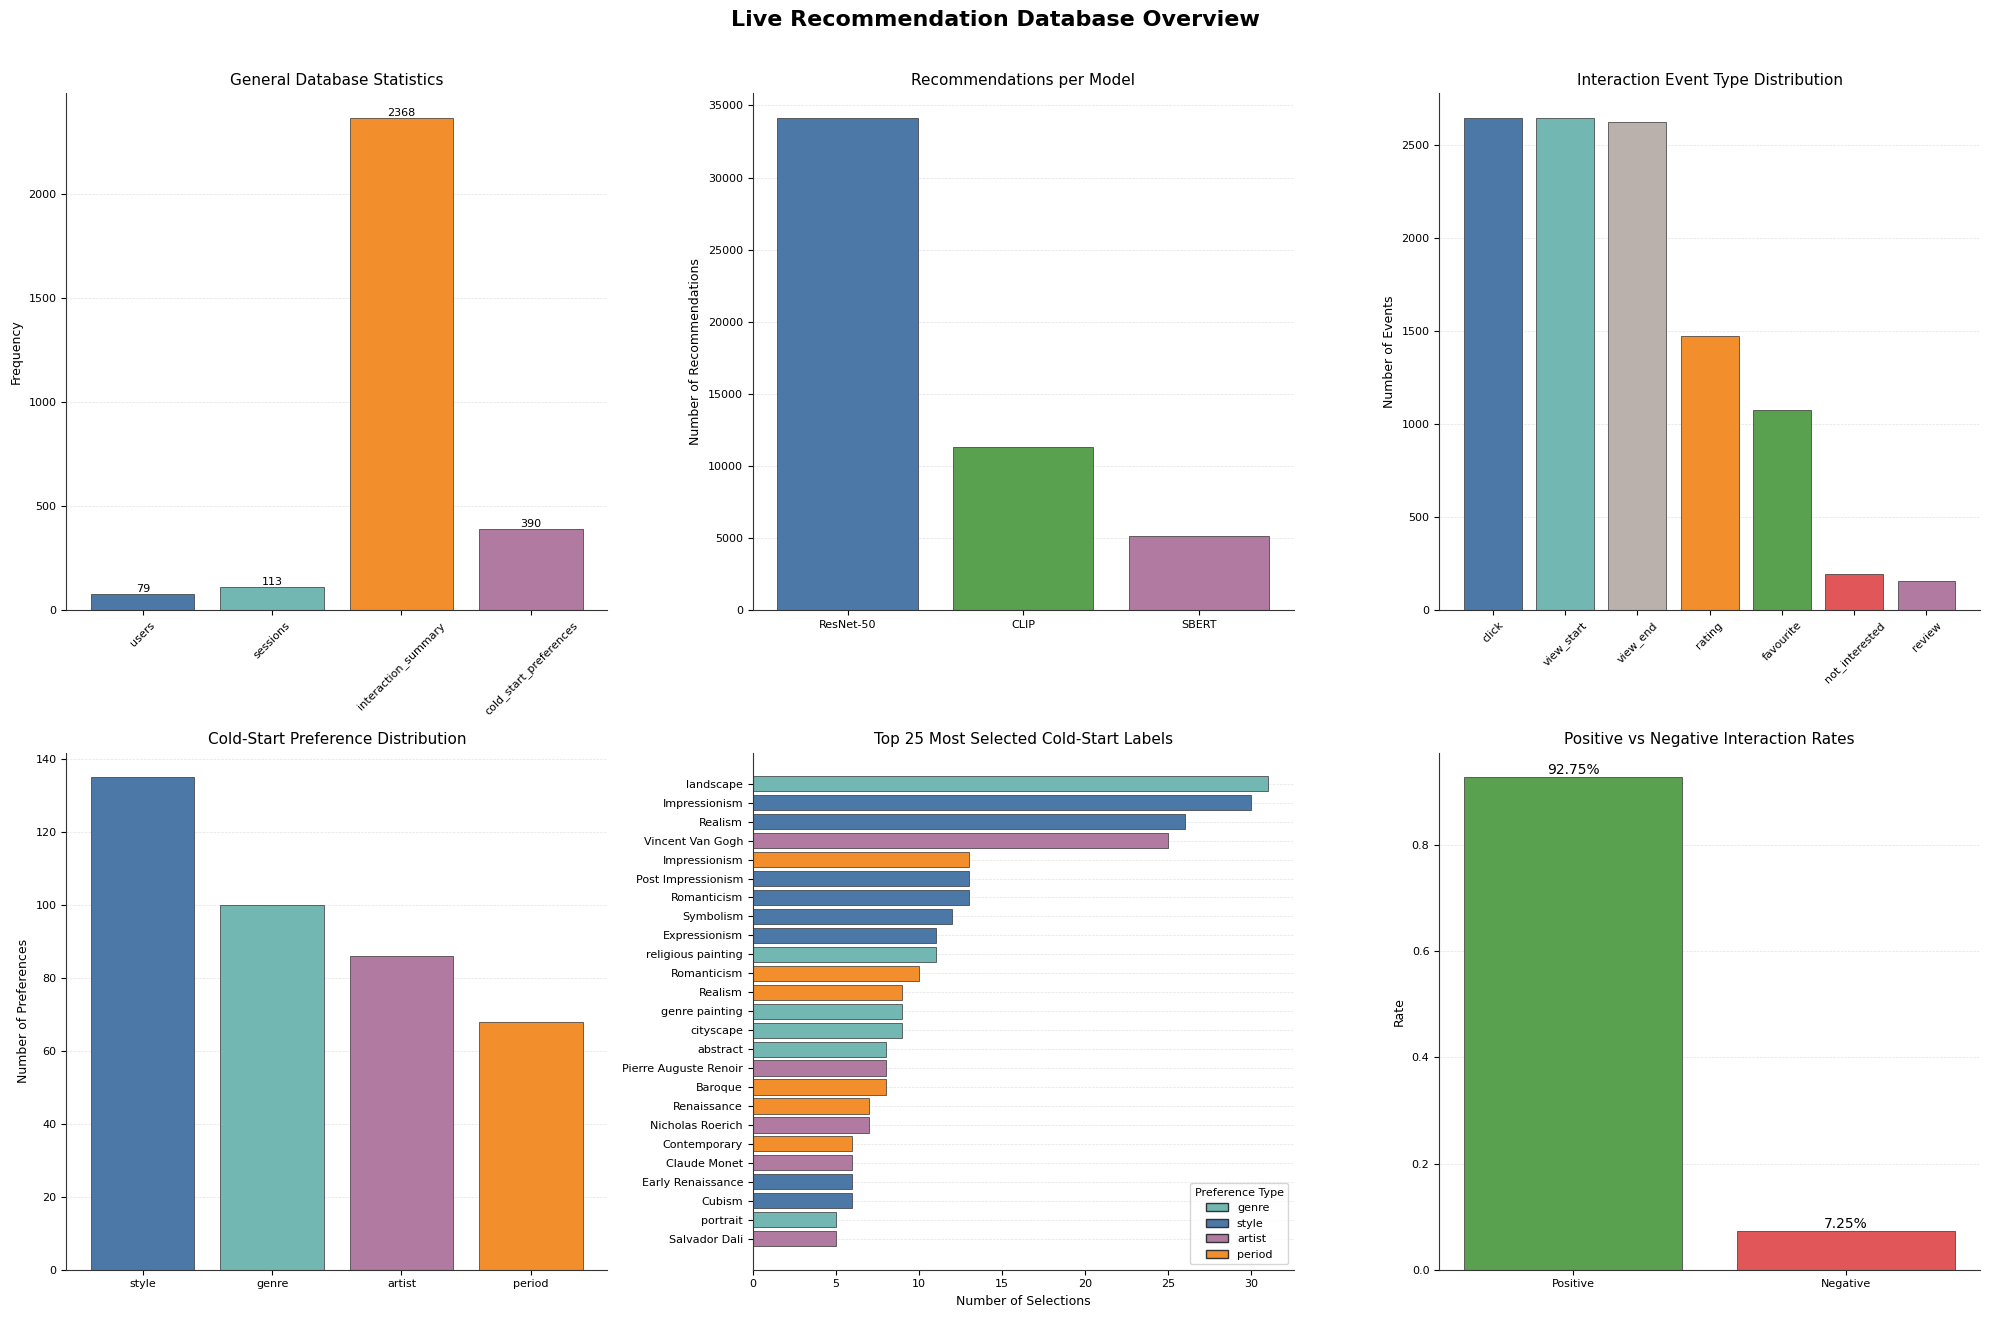

In [97]:
plot_evaluation_database_overview()